<a href="https://colab.research.google.com/github/Zelechos/Pragmatic_IA/blob/master/lang_graph/notebooks/001_Lang_Graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from typing import TypedDict, Dict, Annotated
from operator import add
from langgraph.graph import StateGraph
from IPython.display import Image, display

### Creamos un Esquema de nuestro State con una Clase

In [46]:
# This is normal python
class AgentState(TypedDict):  # Our State Squema
    message: str

### Creamos un nodo que como parametro tiene nuestro esquema de estado y retorna el estado

*esto es una definicion aun no agregamo el nodo a nuestro grafo*

In [55]:
def add_hello(state: AgentState):
    """Simple node that adds  a greeting message to the state"""
    return { "message" : "Hello " + state["message"] }


def greeting_node(state: AgentState):
    """Simple node that adds  a greeting message to the state"""
    return { "message" : state["message"] + " how is your going?"}

## Creamos nuestro grafo

Con ayuda la clase *StateGraph* a la cual le pasamos como parametros nuestro Esquema de Estado *AgentState*


1.   Agregamos nuestro nodo anteriormente definido y lo renombramos con el nombre *greeting*
2.   Creamos en nuestro grafo el punto de entrada y salida con *set_entry_point* y *set_finish_point*
3.   Compilamos nuestro grafo en una app con *graph.compile()*

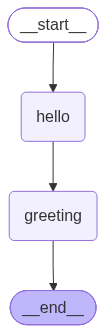

In [56]:
# Now is the time to use LangGraph
graph = StateGraph(AgentState)

# Add node
graph.add_node("greeting", greeting_node)
graph.add_node("hello", add_hello)

graph.set_entry_point("hello")  # Set the entry point
graph.add_edge("hello","greeting") # Set edge
graph.set_finish_point("greeting")# Set the finish point

# Compile the Graph
app = graph.compile()


# To see re results
display(Image(app.get_graph().draw_mermaid_png()))

Una vez compilado nuestro grafo en app invocamos la app con *app.invoke({"attribute":"value"...})* para posteriormente asignar el resultado a una variables llamada result.

In [57]:
result = app.invoke({"message": "Ethernet"})

Show the results

In [58]:
result["message"]

'Hello Ethernet how is your going?'